MSE : 4.7538254116970124
R2 Score : 0.9974289748990282


C:\Users\karti\AppData\Local\Temp\ipykernel_53508\230529237.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(
C:\Users\karti\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


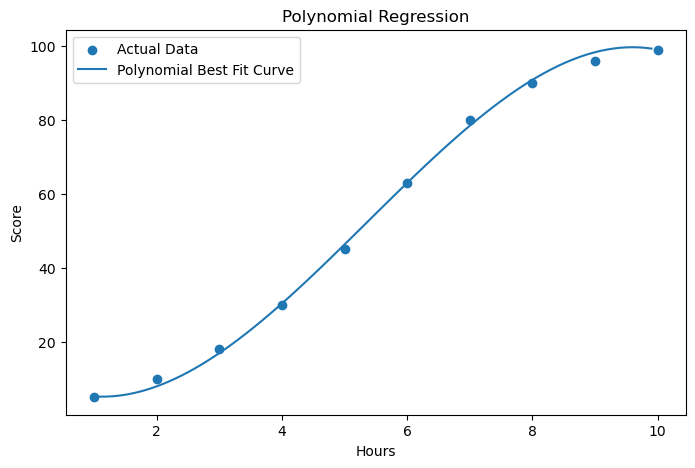

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = {
    'Hours':[1,2,3,4,5,6,7,8,9,10],
    'Score':[5,10,18,30,45,63,80,90,96,99]
}

df = pd.DataFrame(data)

X = df[['Hours']]
y = df['Score']

# Polynomial Features
poly = PolynomialFeatures(degree=3,include_bias=True)

X_poly = poly.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# Smooth Curve
X_grid = np.arange(
    min(X.values),
    max(X.values),
    0.1
).reshape(-1,1)

X_grid_poly = poly.transform(X_grid)
X_grid_scaled = scaler.transform(X_grid_poly)

y_grid_pred = model.predict(X_grid_scaled)

# Plot
plt.figure(figsize=(8,5))

plt.scatter(X, y, label="Actual Data")

plt.plot(
    X_grid,
    y_grid_pred,
    label="Polynomial Best Fit Curve"
)

plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Polynomial Regression")

plt.legend()
plt.show()